In [1]:
import redback 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo

def sn1998bw_template(time, redshift, amplitude, **kwargs):
    """
    A wrapper to the SN1998bw template. Only valid between 1100-11000 Angstrom and 0.01 to 90 days post explosion in rest frame

    Parameters
    ----------
    time
        time in days in observer frame (post explosion)
    redshift
        redshift
    amplitude
        amplitude scaling factor, where 1.0 is the original brightness of SN1998bw; and f_lambda is scaled by this factor
    kwargs
        Additional keyword arguments required by redback.
    frequency
        Required if output_format is 'flux_density'. frequency to calculate - Must be same length as time array or a single number).
    bands
        Required if output_format is 'magnitude' or 'flux'.
    output_format
        'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'
    cosmology
        Cosmology to use for luminosity distance calculation. Defaults to Planck18. Must be a astropy.cosmology object.
    Returns
    -------
        set by output format - 'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'

    """
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    tts = np.geomspace(0.01, 90, 200)
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(tts, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = tts * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)


# After pasting the function definition into your cell:
from redback.model_library import all_models_dict

all_models_dict['sn1998bw_template'] = sn1998bw_template

# Now any redback functions that look in the dictionary will find it!


No module named 'lalsimulation'
lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model
14:23 bilby INFO    : Running bilby version: 2.3.0
14:23 redback INFO    : Running redback version: 1.12.1


In [2]:
# func = all_models_dict['sn1998bw_template']

# #INFO FOR GRB 060505
# #from jillian: 
# #Time (day),Bandpass,Vega Mag,σ (mag),Instrument,Reference,AB Mag
# #1.102,r,21.65,0.16,GMOS,1,21.81,1

# #WHT ABOUT LATER TIMES: 
# #9.105,i,>22.96,...,GMOS,1,23.33,0

# #HAVE TO USE AB FILTERS !! i cant correct the flux density at all - xould do post model output ? then not a direct comparison ? 

# # time = np.array((1.102)) 
# # red = 0.089
# # freq = 4.85800e+14 #r

# time = np.array((9.105)) 
# red = 0.089
# freq = 4.00500e+14#i

# sn_1998b2 = func(time=time,redshift=red,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)
# sn_1998b1 = func(time=time,redshift=0.0085,amplitude=1.0,frequency=freq,output_format='flux_density', cosmology=cosmo)

# print(sn_1998b2, sn_1998b1, sn_1998b2/sn_1998b1)

# #why does this code not require any wavelenegth ?? is this working more correctly than the other one ? 

# #purely using model here to find flux density of GRB event 
# #f_98 andrew value for 060505 = <0.01 so very small - yes we get a very small value too at 1.102 days, what about at 9 days ? still 0.01 so yes this works when model only is used

# #verify with AI what this is actually doing and why model works over known flux density? 

In [3]:
#grb info:
#taken from jillians files
#Time (day),Bandpass,Vega Mag,σ (mag),Instrument,Reference,AB Mag
#1.125,B,22.48,0.04,VLT+FORS1,2,22.39,1

#LATER TIME OBSERVATION -- HAS TO BE IN B BAND ? TRY ANOTHER ONE 
#Time (day),Bandpass,Vega Mag,σ (mag),Instrument,Reference,AB Mag
#18.0,R,>24.95,...,VLT+FORS2,2,25.16,0

time = 18.0 #days post explosion -- too early of a time ? 
red = 0.089
AB_mag = 24.95 + 0.21 #R band filter 
#OR USE ab MAG GIVEN IN jillians table 25.16 - same thing as my correction !! 
target_frequencies = 4.61700e+14 #R band Hz
wavelength = np.array([6498.09000])
target_milky_way_ebv = 0  #from literautre less than 1.04 (MIGHT HAVE TO CHANGE THIS VALUE - WHAT RATIO DOES THIS GIVE )-- change to 0 - different result ? 

a_v = target_milky_way_ebv  * 3.1
#WITH GAVINS IMPROVED FUNCTION: 

all_models_dict['sn1998bw_template'] = sn1998bw_template

func1 = all_models_dict['sn1998bw_template']

sn_1998bw1= func1(time=time,
                 redshift=red, #redshift of actual event 
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#calculate dereddened flux density of GRB evnet: 
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")

#calculate and print final ratio 
flux_ratio = dereddened_flux_event / sn_1998bw1
print(flux_ratio[0])

#WRONG ?! too much of an early time observation try a later one 
#what source did andrew use ? <0.01  -- i get 0.02 so close ? -- try for other sources 

This is the flux density of  GRB event without extinction correction: 0.00031 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 0.00031 mJy
0.002757185569702097 mJy


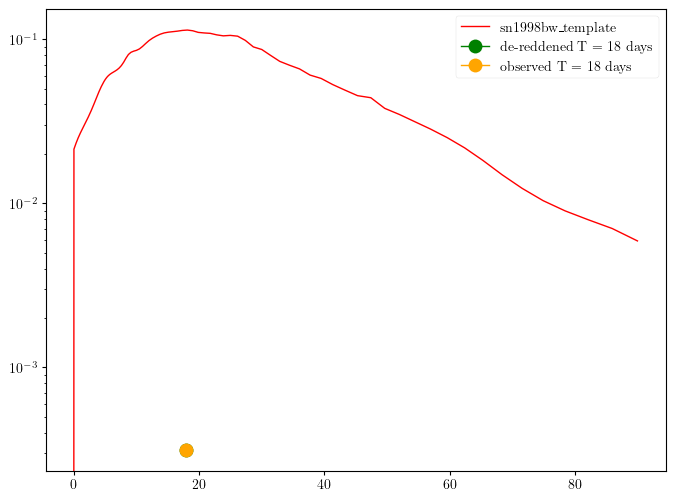

In [4]:
times = np.geomspace(0.01,90,200)

sn_1998bw1= func1(time=times,
                 redshift=red,
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )

#make new functions for specific times to bcompare the baseline points on the plot


plt.figure(figsize = (8,6))
plt.semilogy(times,sn_1998bw1, '-r', label = 'sn1998bw_template')
#how do i get these other values to work ?? 
plt.semilogy(time, dereddened_flux_event[0], marker='o',color='green', markersize = 10, label = 'de-reddened T = 18 days') #dereddened flux density points for GRB event 
plt.semilogy(time, flux_density_event, marker='o',color='orange', markersize = 10, label = 'observed T = 18 days ') #observed (reddened) flux density points for GRB event -- issue with this point -- re run ? -- fixed !! 
plt.legend()
plt.show()